# MNIST Semi-Supervised Classification (100 Labels)

Convolutional autoencoder + clustering on the **MNIST digit** dataset (28×28 grayscale handwritten digits, 10 classes). The constraint: only **100 training labels** are allowed, but you may choose *which* 100 images to label.

## Goal

Reach **>92.5% test accuracy** without labeling the full 55,000-image training set. The unlabeled images still get used — the autoencoder learns a representation from every pixel, then k-means picks a diverse set of 100 examples to label.

## Pipeline

1. Train a convolutional **autoencoder** on all unlabeled training images.
2. Cluster the 16-d latent codes with **k-means (k = 100)** and label the image nearest each centroid.
3. **Propagate** each centroid’s label to nearby points in latent space (keep the closest 70% of each cluster).
4. Train a classifier on those pseudo-labeled images. One branch is a small CNN; the other is the **frozen encoder**.


## 1. Load Digit MNIST

Normalize to [0, 1]. Last 5,000 of the official training split are validation. Reshape to `(N, 28, 28, 1)`.


In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
x_train_full = x_train_full.astype(np.float32) / 255
x_test = x_test.astype(np.float32) / 255
x_train, x_valid = x_train_full[:-5000], x_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]


In [ ]:
print(x_train.shape, x_valid.shape, x_test.shape)


(55000, 28, 28) (5000, 28, 28) (10000, 28, 28)


In [ ]:
image_size = x_train.shape[1]
x_train = np.reshape(x_train, [-1, image_size, image_size, 1])
x_valid = np.reshape(x_valid, [-1, image_size, image_size, 1])
x_test = np.reshape(x_test, [-1, image_size, image_size, 1])


First 100 training digits (still unlabeled for our budget).


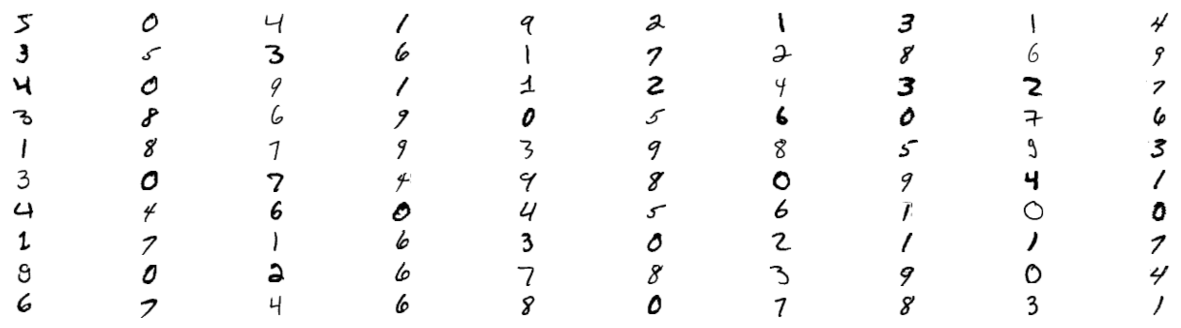

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 4))
for index, digit in enumerate(x_train[:100]):
    plt.subplot(100 // 10, 10, index + 1)
    plt.imshow(digit.reshape(28, 28), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()


## 2. Convolutional Autoencoder

Encoder: conv layers with stride-2 downsampling, flatten, dense to a 16-d latent vector. Decoder: dense → reshape → `Conv2DTranspose` back to 28×28×1 with sigmoid pixels. Train with MSE reconstruction loss and early stopping.


In [ ]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D, Flatten, Dropout
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
latent_dim = 16
batch_size = 128


In [ ]:
inputs = Input(shape=(28, 28, 1), name="ae_input")
x = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x = Conv2D(32, (3, 3), padding="same", strides=2, activation="relu")(x)
x = Conv2D(64, (3, 3), padding="same", strides=2, activation="relu")(x)


In [ ]:
shape = K.int_shape(x)
x = Flatten()(x)
z = Dense(latent_dim, name="latent")(x)
encoder = Model(inputs, z, name="encoder")


Decoder and full autoencoder (encoder + decoder).


In [ ]:
latent_inputs = Input(shape=(latent_dim,), name="z_input")
x = Dense(shape[1] * shape[2] * shape[3], activation="relu")(latent_inputs)
x = Reshape((shape[1], shape[2], shape[3]))(x)


In [ ]:
x = Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")  (x)
x = Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")  (x)


In [ ]:
outputs = Conv2DTranspose(1, (3, 3), padding="same", activation="sigmoid")(x)
decoder = Model(latent_inputs, outputs, name="decoder")
auto_outputs = decoder(encoder(inputs))
autoencoder = Model(inputs, auto_outputs, name="autoencoder")


In [ ]:
autoencoder.compile(loss='mse', optimizer='adam')


Train the autoencoder to reconstruct its input. `restore_best_weights` keeps the checkpoint with the lowest validation loss.


In [ ]:
history = autoencoder.fit(x_train,
                x_train,
                validation_data=(x_valid, x_valid),
                epochs=100,
                batch_size=batch_size, callbacks=[EarlyStopping(patience=20, restore_best_weights=True)])


Epoch 1/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0810 - val_loss: 0.0136
Epoch 2/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0127 - val_loss: 0.0107
Epoch 3/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0102 - val_loss: 0.0095
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0092 - val_loss: 0.0089
Epoch 5/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0086 - val_loss: 0.0084
Epoch 6/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0081 - val_loss: 0.0081
Epoch 7/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0078 - val_loss: 0.0079
Epoch 8/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0076 - val_loss: 0.0077
Epoch 9/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0073 - val_loss: 0.0075
Epoch 10/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0072 - val_loss: 0.0074
Epoch 11/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0070 - val_loss: 0.0073
Epoch 12/100
430/430 ━━━━━━━━━━━━━━━━━━━

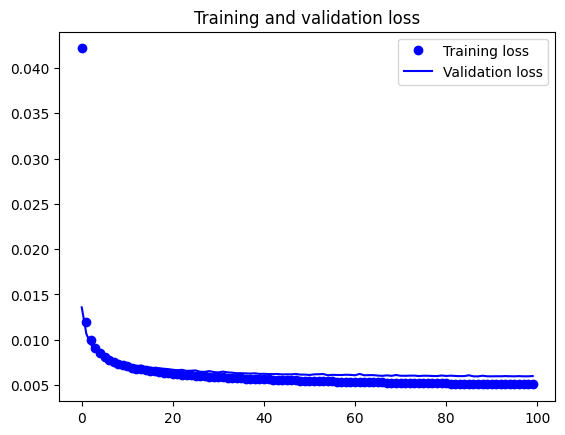

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()


Encode the training and validation sets into 16-d codes.


In [ ]:
x_train_encoded = encoder.predict(x_train)
x_valid_encoded = encoder.predict(x_valid)
print(x_train_encoded.shape, x_valid_encoded.shape)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(55000, 16) (5000, 16)


## 3. Choose 100 Images via k-means

Cluster latent codes into 100 groups. For each cluster, take the training image **closest to the centroid** — those 100 become the only images we label (true MNIST labels for those indices).


In [ ]:
from sklearn.cluster import KMeans


In [ ]:
k = 100
kmeans = KMeans(n_clusters=k, random_state=0)
cluster_ids = kmeans.fit_predict(x_train_encoded)
x_representative_digits = []
representative_digit_idx = []
for i in range(k):
    idxs = np.where(cluster_ids == i)[0]
    cluster_latents = x_train_encoded[idxs]
    centroid = kmeans.cluster_centers_[i]
    distances = np.linalg.norm(cluster_latents - centroid, axis=1)
    closest = idxs[np.argmin(distances)]
    x_representative_digits.append(x_train[closest])
    representative_digit_idx.append(closest)
x_representative_digits = np.array(x_representative_digits)
representative_digit_idx = np.array(representative_digit_idx)


Display the 100 representatives and record their labels.


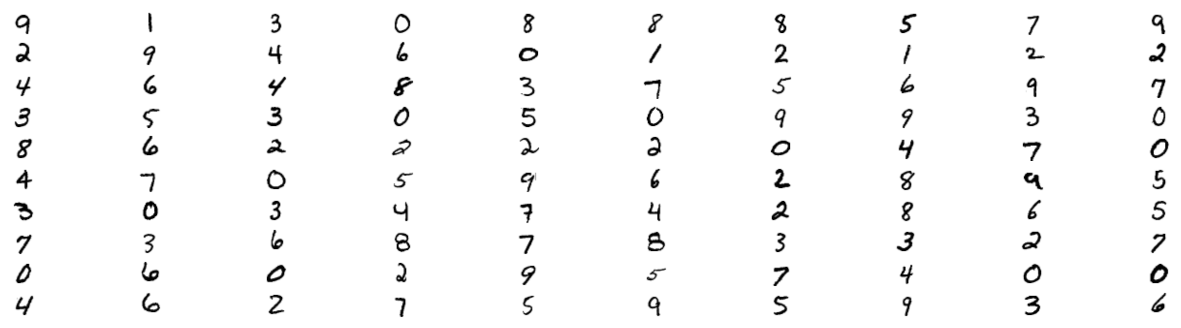

In [ ]:
plt.figure(figsize=(16, 4))
for index, x_representative_digit in enumerate(x_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(x_representative_digit.reshape(28, 28), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()


In [ ]:
y_representative_digits = np.empty([k])
for i, idx in enumerate(representative_digit_idx):
  y_representative_digits[i] = y_train[idx]
print(y_representative_digits)


[9. 1. 3. 0. 8. 8. 8. 5. 7. 9. 2. 9. 4. 6. 0. 1. 2. 1. 2. 2. 4. 6. 4. 8.
 3. 7. 5. 6. 9. 7. 3. 5. 3. 0. 5. 0. 9. 9. 3. 0. 8. 6. 2. 2. 2. 2. 0. 4.
 7. 0. 4. 7. 0. 5. 9. 6. 2. 8. 9. 5. 3. 0. 3. 4. 7. 4. 2. 8. 6. 5. 7. 3.
 6. 8. 7. 8. 3. 3. 2. 7. 0. 6. 0. 2. 9. 5. 7. 4. 0. 0. 4. 6. 2. 7. 5. 9.
 5. 9. 3. 6.]


In [ ]:
print(x_representative_digits.shape)
print(y_representative_digits.shape)


(100, 28, 28, 1)
(100,)


## 4. Label Propagation

Assign every training point its cluster’s representative label, then drop the farthest 30% of each cluster (`percentile_closest = 70`) so noisy boundary points are not used as training labels.


In [ ]:
y_train_propagated = np.empty(len(x_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]


In [ ]:
x_digits_dist = np.zeros((len(x_train_encoded), k))
for i in range(k):
    c = kmeans.cluster_centers_[i]
    x_digits_dist[:, i] = np.linalg.norm(x_train_encoded - c, axis=1)
percentile_closest = 70
x_cluster_dist = x_digits_dist[np.arange(len(x_train_encoded)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = x_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (x_cluster_dist > cutoff_distance)
    x_cluster_dist[in_cluster & above_cutoff] = -1


Keep only propagated examples, then hold out 5,000 of those for validation of the classifier. One-hot encode labels.


In [ ]:
partially_propagated = (x_cluster_dist != -1)
x_train_partially_propagated = x_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]


In [ ]:
print(x_train_partially_propagated.shape)
print(y_train_partially_propagated.shape)


(38484, 28, 28, 1)
(38484,)


In [ ]:
x_rep_train = x_train_partially_propagated[:-5000]
y_rep_train = y_train_partially_propagated[:-5000]
x_rep_valid = x_train_partially_propagated[-5000:]
y_rep_valid = y_train_partially_propagated[-5000:]


In [ ]:
print(x_rep_train.shape, x_rep_valid.shape)


(33484, 28, 28, 1) (5000, 28, 28, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical
train_labels = to_categorical(y_rep_train)
valid_labels = to_categorical(y_rep_valid)
test_labels = to_categorical(y_test)


## 5. Classifier: CNN Branch + Frozen Encoder

Left input: two conv/pool blocks on the image. Right input: the **frozen** autoencoder encoder (latent features). Concatenate, dense layers, 10-way softmax. Train with Nadam and early stopping on validation accuracy.


In [ ]:
from keras import layers
from keras import models
def build_model():
    left_inputs  = layers.Input(shape=(28, 28, 1), name="left_image")
    right_inputs = layers.Input(shape=(28, 28, 1), name="right_image")
    l = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(left_inputs)
    l = layers.MaxPooling2D((2, 2))(l)
    l = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(l)
    l = layers.MaxPooling2D((2, 2))(l)
    l = layers.Flatten()(l)
    l = layers.Dropout(0.3)(l)
    encoder.trainable = False
    r = encoder(right_inputs)
    r = layers.Dense(64, activation="relu")(r)
    x = layers.Concatenate()([l, r])
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model([left_inputs, right_inputs], outputs=outputs)
    return model
model = build_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_image          │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │        320 │ left_image[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 64)  │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_image         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 3136)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 16)        │     78,256 │ right_image[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 3136)      │          0 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      1,088 │ encoder[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3200)      │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │    409,728 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │      1,290 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 509,178 (1.94 MB)

 Trainable params: 430,922 (1.64 MB)

 Non-trainable params: 78,256 (305.69 KB)

In [ ]:
model.compile(optimizer='nadam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
history = model.fit([x_rep_train, x_rep_train], train_labels, validation_data=([x_rep_valid, x_rep_valid], valid_labels), epochs=100, batch_size=32,
                    callbacks=[EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)])


Epoch 1/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9060 - loss: 0.3209 - val_accuracy: 0.9870 - val_loss: 0.0372
Epoch 2/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9842 - loss: 0.0467 - val_accuracy: 0.9912 - val_loss: 0.0289
Epoch 3/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9896 - loss: 0.0316 - val_accuracy: 0.9904 - val_loss: 0.0281
Epoch 4/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9916 - loss: 0.0247 - val_accuracy: 0.9898 - val_loss: 0.0257
Epoch 5/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9926 - loss: 0.0212 - val_accuracy: 0.9922 - val_loss: 0.0237
Epoch 6/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9938 - loss: 0.0179 - val_accuracy: 0.9904 - val_loss: 0.0275
Epoch 7/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9937 - loss: 0.0175 - val_accuracy: 0.9906 - val_loss: 0.0229
Epoch 8/100
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9947 - loss: 

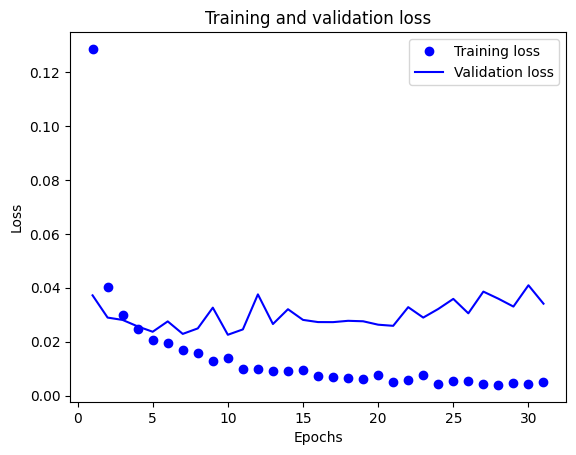

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


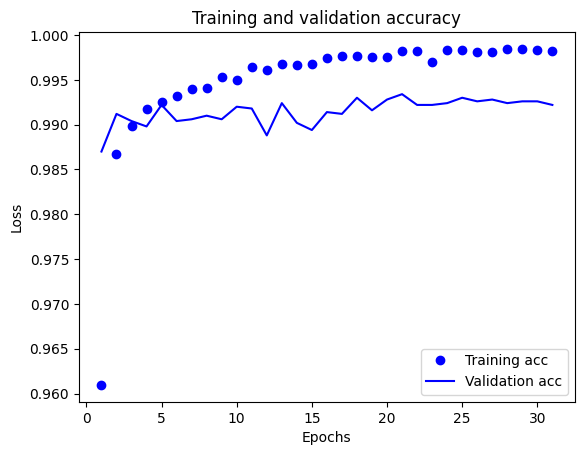

In [ ]:
plt.clf()
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 6. Test-Set Evaluation

Run this only after validation accuracy looks good — the test set is a single final check.


In [ ]:
test_loss, test_acc = model.evaluate([x_test, x_test], test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9484 - loss: 0.4166


## Summary

With a good latent space, 100 carefully chosen labels plus propagation can rival training on tens of thousands of labels. The autoencoder is trained without labels; clustering decides *which* examples are worth labeling; the classifier reuses the encoder as a feature extractor.
